### Major refactoring
Since I have so many layers and parameters, I am going to need a better way to organize them. I'm also going to be adding LayerNorm so wayyyy too many parameters in general. 
I'm going to use `nn.Module` class and create my own model.

In [16]:
import torch
import torch.nn as nn
from torch.nn import functional as F

device = 'cuda' if torch.cuda.is_available() else 'cpu'
words = open('../data/names.txt', 'r').read().splitlines()
device

'cuda'

In [21]:
# encode chars to integers
chars = sorted(list(set(''.join(words))))
stoi = { ch:i+1 for i,ch in enumerate(chars)}
stoi['.'] = 0
itos = { i:ch for ch,i in stoi.items()}
vocab_size = len(itos)

encode = lambda s: [stoi[c] for c in s]
decode = lambda l: ''.join([itos[i] for i in l])

In [4]:
# hyperparameters
block_size = 16
batch_size = 32

emb_size = 32
n_hidden = 64

In [22]:
# build dataset
def build_dataset(words):
    X, Y = [], []

    for w in words:
        context = [0] * block_size
        # sliding window
        for ch in w + '.':
            ix = stoi[ch] # encode(ch)
            X.append(context)
            Y.append(ix)
            context = context[1:] + [ix]
    
    X = torch.tensor(X)
    Y = torch.tensor(Y)
    X, Y = X.to(device), Y.to(device)

    return X, Y

n1 = int(0.9*len(words))

X, Y = build_dataset(words)
Xtr, Ytr = build_dataset(words[:n1])
Xval, Yval = build_dataset(words[n1:])

def get_batch(split):
    dataX = Xtr if split == 'train' else Xval
    dataY = Ytr if split == 'train' else Yval

    ix = torch.randint(low=0, high=dataX.shape[0], size=(batch_size, ))
    x = torch.stack([dataX[i] for i in ix])
    y = torch.stack([dataY[i] for i in ix])
    return x, y


print(X[:5])
print(Y[:5])
len(Xtr)

tensor([[ 0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0],
        [ 0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  5],
        [ 0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  5, 13],
        [ 0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  5, 13, 13],
        [ 0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  5, 13, 13,  1]],
       device='cuda:0')
tensor([ 5, 13, 13,  1,  0], device='cuda:0')


205411

For fun, I will recreate some boilerplate layers.

In [23]:
class Linear(nn.Module):
  def __init__(self, fan_in, fan_out, bias=True):
    super().__init__()
    self.weight = nn.Parameter(torch.randn((fan_in, fan_out)) / fan_in**0.5) # note: kaiming init
    self.bias = nn.Parameter(torch.zeros(fan_out)) if bias else None
  
  def forward(self, x):
    out = x @ self.weight
    if self.bias is not None:
      out += self.bias
    return out

In [24]:
class Flatten(nn.Module):
    def __init__(self, factor=1):
        super().__init__()
        self.factor = factor
        
    def forward(self, idx):
        B, T, C = idx.shape
        idx = idx.view(B, T//self.factor, C*self.factor)
        if idx.shape[1] == 1:
            idx = idx.squeeze(dim=1)
        return idx

In [25]:
class DilatedLayer(nn.Module):
    def __init__(self, fan_in, factor=1):
        super().__init__()
        self.net = nn.Sequential(
            Flatten(factor),
            Linear(fan_in, n_hidden, bias=False),
            nn.Tanh()
        )

    def forward(self, idx):
        return self.net(idx)

In [26]:
class DilatedCasualConvolutions(nn.Module):
    def __init__(self, n_flattens=1):
        super().__init__()
        factor = int(block_size **  (1/n_flattens))
        self.flattens = nn.Sequential(
            DilatedLayer(factor * emb_size, factor), *[DilatedLayer(factor * n_hidden, factor) for _ in range(n_flattens-1)]
        )

    def forward(self, idx):
        return self.flattens(idx)
        

In [19]:
tok_emb = nn.Embedding(vocab_size, emb_size) 
pos_emb = nn.Embedding(block_size, emb_size)
flatten = Flatten(16)
initflattenLayer = nn.Sequential(Flatten(16), Linear(16 * emb_size, n_hidden, bias=False), nn.Tanh())
# deepflattenLayer = nn.Sequential(Flatten(2), Linear(2 * n_hidden, n_hidden, bias=False), nn.Tanh())
# dilatedcnn = nn.Sequential(initflattenLayer, deepflattenLayer, deepflattenLayer, deepflattenLayer)
dilatedcnn = DilatedCasualConvolutions(n_flattens=block_size.bit_length() - 1)

unembed = Linear(n_hidden, vocab_size) # 64, 27
Xb, Yb = get_batch('train') # cuda

tok_emb.to(device)
pos_emb.to(device)
unembed.to(device)
flatten.to(device)
dilatedcnn.to(device)
initflattenLayer.to(device)
#deepflattenLayer.to(device)

B, T = Xb.shape
tok = tok_emb(Xb) # 32, 16, 64
pos = pos_emb(torch.arange(T, device=device)) # 16, 64
x = tok + pos # 32, 16, 64

x = dilatedcnn(x)
print(x.shape)
# x = x.view(x.shape[0], -1) # 32, 16*64
logits = unembed(x) # 32, 27
logits.shape
F.cross_entropy(logits, Yb)

# print(Xb[:1])
#print(torch.zeros((1, block_size), dtype=int))

torch.Size([32, 64])


tensor(3.5422, device='cuda:0', grad_fn=<NllLossBackward0>)

In [405]:
n_flattens = block_size.bit_length() - 1
factor = int(block_size **  (1/n_flattens))
factor

2

In [ ]:
class WaveNet(nn.Module):

    def __init__(self):
        super().__init__()

        self.tok_emb = nn.Embedding(vocab_size, emb_size)
        self.pos_emb = nn.Embedding(block_size, emb_size)
        self.dilated = DilatedCasualConvolutions(n_flattens = block_size.bit_length() - 1) # n.bit_length() - 1 = log2(n)
        self.unembed = Linear(n_hidden, vocab_size)

        self.apply(self._init_weights)
    
    def _init_weights(self, module):
        if isinstance(module, nn.Linear):
            torch.nn.init.normal_(module.weight, mean=0.0, std=0.02)
            if module.bias is not None:
                torch.nn.init.zeros_(module.bias)
        elif isinstance(module, nn.Embedding):
            torch.nn.init.normal_(module.weight, mean=0.0, std=0.02)

    def forward(self, idx, targets=None):
        B, T = idx.shape

        tok_emb = self.tok_emb(idx)
        pos_emb = self.pos_emb(torch.arange(T, device=device))

        x = tok_emb + pos_emb
        # x = x.view(x.shape[0], -1) 
        x = self.dilated(x)
        logits = self.unembed(x)

        if targets is None:
            loss = None
        else:
            loss = F.cross_entropy(logits, targets)

        return logits, loss

    def generate(self, idx=None,  max_new_tokens=100):
        if idx == None:
            idx = torch.zeros((1, block_size), dtype=int, device=device)
            
        out = []
        print(idx)
        print(idx.shape)
        for _ in range(max_new_tokens):
            logits, _ = self(idx)
            probs = F.softmax(logits, dim=1)
            ix = torch.multinomial(probs, num_samples=1).item()

            idx = torch.cat((idx[:, 1:], torch.tensor([[ix]], device=device)), dim=1)

            out.append(decode([ix]))
            if ix == 0:
                break
        return out


In [28]:
model = WaveNet()
model.to(device=device)
Xb, Yb = get_batch('train')
logits, loss = model(Xb, Yb)
# while True:
#     idx = torch.zeros((1, block_size), dtype=int, device=device)

#     logits, loss = model(idx)
#     probs = F.softmax(logits, dim=1)
#     ix = torch.multinomial(probs, num_samples=1).item()

#     print(decode([ix]))
#     idx = torch.cat((idx[:, 1:], torch.tensor([[ix]], device=device)), dim=1)
#     if ix == 0:
#         break
"".join(model.generate())

tensor([[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]], device='cuda:0')
torch.Size([1, 16])


'xlxk.'

In [30]:
max_iters = 100000
eval_interval = max_iters // 5
lr = 4e-4

model = WaveNet()
model.to(device=device)
model.load_state_dict(torch.load("parametersV3.pt", weights_only=True))
print(sum(p.numel() for p in model.parameters()))

optimizer = torch.optim.AdamW(model.parameters(), lr=lr)
lossi = []
for iter in range(max_iters):
    Xb, Yb = get_batch('train')
    logits, loss = model(Xb, Yb)

    optimizer.zero_grad(set_to_none=True)
    loss.backward()
    optimizer.step()

    if iter % eval_interval == 0 or iter == max_iters - 1:
        print(loss.item())
    lossi.append(loss.item())

torch.save(model.state_dict(), "parametersV3.pt")

31803
1.5729788541793823
2.223176956176758
2.1248743534088135
2.078861951828003
1.6754499673843384
2.069132089614868


In [ ]:
# torch.tensor(encode())
torch.zeros((1, block_size), dtype=int, device=device).shape
context = [0] * block_size
c = "hello"
context = context[:block_size - len(c)] + encode(c) 
context = torch.tensor([context])
context = context.to(device)
c + "".join(model.generate(idx=context))

tensor([[ 0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  8,  5, 12, 12, 15]],
       device='cuda:0')
torch.Size([1, 16])


'hellon.'

In [20]:
import matplotlib.pyplot as plt
%matplotlib inline
plt.figure(figsize=(10, 5))
plt.plot(lossi)
min(lossi)

NameError: name 'lossi' is not defined

<Figure size 1000x500 with 0 Axes>

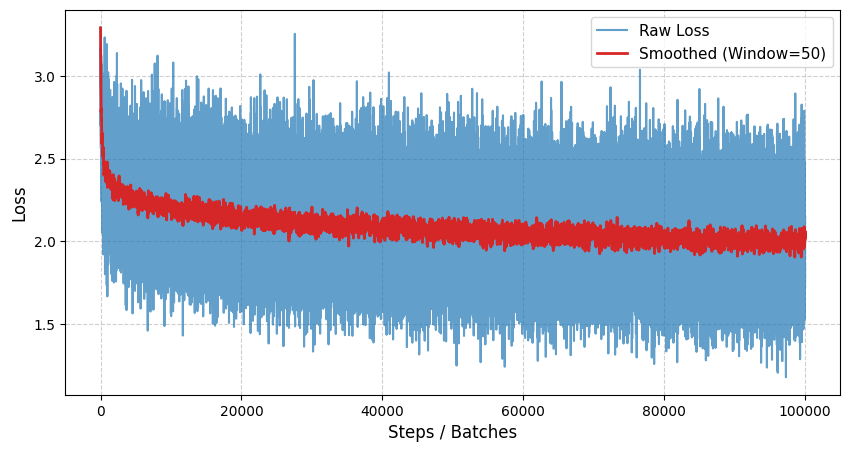

In [20]:
import matplotlib.pyplot as plt
import pandas as pd

smoothed_loss = pd.Series(lossi).rolling(window=50, min_periods=1).mean()

plt.figure(figsize=(10, 5))

plt.plot(lossi, alpha=0.7, color='#1f77b4', label='Raw Loss')
plt.plot(smoothed_loss, color='#d62728', linewidth=2, label='Smoothed (Window=50)')

plt.xlabel('Steps / Batches', fontsize=12)
plt.ylabel('Loss', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(fontsize=11)

plt.show()

In [28]:
@torch.no_grad()
def split_loss(split):
    x, y = {
        'train': (Xtr, Ytr),
        'val': (Xval, Yval)
    }[split]
    x.to(device)
    y.to(device)
    _, loss = model(x, y)
    print(split, loss.item())

split_loss('train')
split_loss('val')

train 1.996289849281311
val 2.2697482109069824
